## 1. Imports & Generate Data

In [41]:
# Imports
import math
import numpy as np
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

from artificial_dataset import make_anomaly_dataset, SpikeParams
from altx import ALT as Altx

from optimized_find_peaks import (
    OptimizedFindPeaks,
    _as_index_mask,
    _make_metric_scorer
)

RANDOM_SEED = 42
TOLERANCE = 5

In [16]:
data = make_anomaly_dataset(
    series_length=2000,
    noise_std=0.4,
    x_range=(0.0, 30.0 * math.pi),
    spike_params=SpikeParams(
        amplitude_range=(3.5, 8.5),
        width_range=(1, 6),
        count_range=(30, 60),
        margin=20,
    ),
    split=(0.6, 0.2, 0.2), # (Ttrain, validation, test)
    random_state=RANDOM_SEED,
)

train, val, test = data.train, data.val, data.test # only renaming

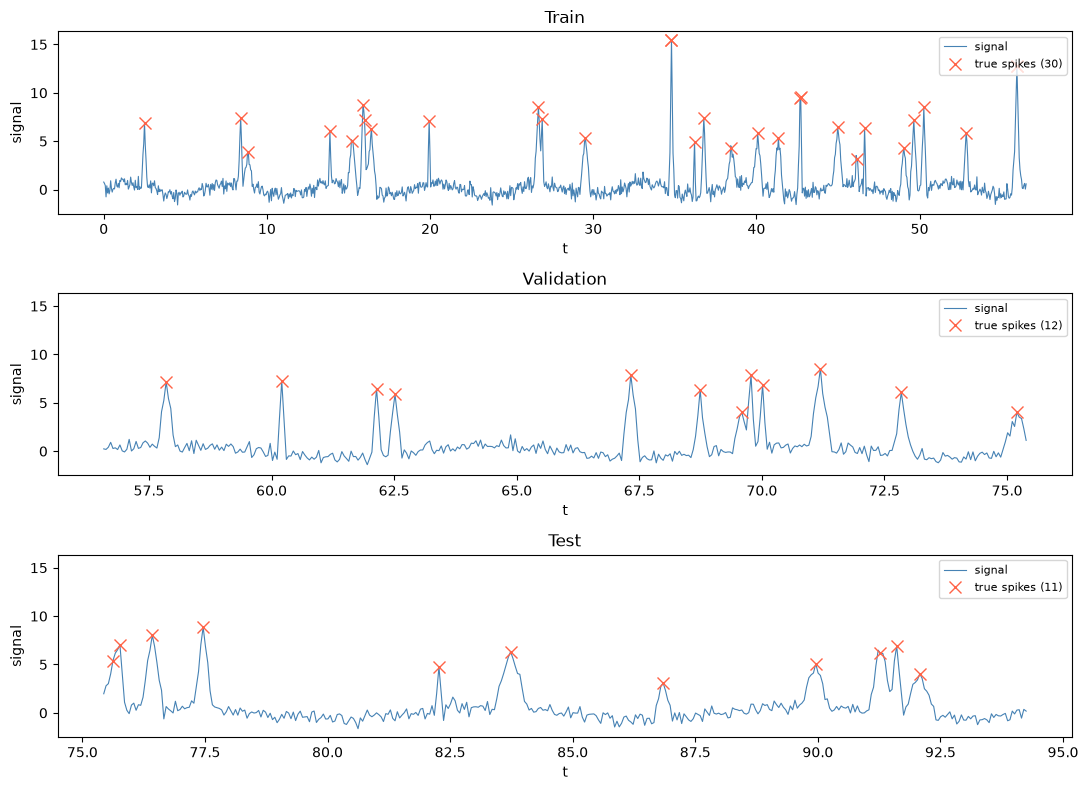

In [17]:
# Visualize the data
def plot_series(ds, ax, title):
    sig = ds.y[0].numpy()
    t = ds.t.numpy()
    pk = ds.peak_indices.numpy()
    ax.plot(t, sig, lw=0.8, color="steelblue", label="signal")
    ax.plot(t[pk], sig[pk], "x", ms=9, color="tomato",
            label=f"true spikes ({pk.size})")
    ax.set_title(title)
    ax.set_xlabel("t")
    ax.set_ylabel("signal")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharey=True)
plot_series(train, axes[0], "Train")
plot_series(val, axes[1], "Validation")
plot_series(test, axes[2], "Test")
plt.tight_layout()
plt.show()

In [27]:
print(train.y)

tensor([[0.7708, 0.6232, 0.4168,  ..., 0.6347, 0.0449, 0.5831]])


## 2. Baseline Optimizer

In [18]:
def channel0(ds):
    '''Return the first channel of a split as a 1-D numpy array.'''
    return ds.y[0].numpy()


def peak_f1(signal, true_peaks, optimizer, tolerance=TOLERANCE):
    '''F1 of an optimizer's detections on `signal`, matched to `true_peaks`.

    Uses the exact same peak-matching metric that `OptimizedFindPeaks`
    optimizes, so the score is comparable to `optimizer.best_score_`.
    '''
    signal = np.asarray(signal, dtype=float).ravel()
    true_mask = _as_index_mask(np.asarray(true_peaks), signal.shape[0])
    pred_peaks, _ = optimizer.predict(signal)
    scorer = _make_metric_scorer("f1", tolerance)
    return scorer(true_mask, pred_peaks, signal.shape[0]), pred_peaks

In [37]:
# Concatenate train val
trainval_signal = np.concatenate([channel0(train), channel0(val)])
trainval_peaks = np.concatenate(
    [train.peak_indices.numpy(), val.peak_indices.numpy() + train.y.shape[1]]
)

baseline_opt = OptimizedFindPeaks(
    scorer="f1",
    n_trials=200,
    tolerance=TOLERANCE,
    seed=RANDOM_SEED,
)
baseline_opt.fit(trainval_signal, trainval_peaks)

baseline_test_f1, baseline_test_peaks = peak_f1(
    channel0(test), test.peak_indices.numpy(), baseline_opt
)
# returns the F1 score and the number of peaks


# Logging
print(f"Best params            : {baseline_opt.best_params_}")
print(f"F1 score (train + val) : {baseline_opt.best_score_:.3f}")
print(f"F1 score on TEST       : {baseline_test_f1:.3f}")
print(f"Detected peaks         : {baseline_test_peaks.size} from {test.peak_indices.shape[0]} peaks on test data.")

Best params            : {'height': 2.0234271327752724, 'prominence': 1.615008473520064, 'distance': 2}
F1 score (train + val) : 0.974
F1 score on TEST       : 0.952
Detected peaks         : 10 from 11 peaks on test data.


### 2.1. Visualization

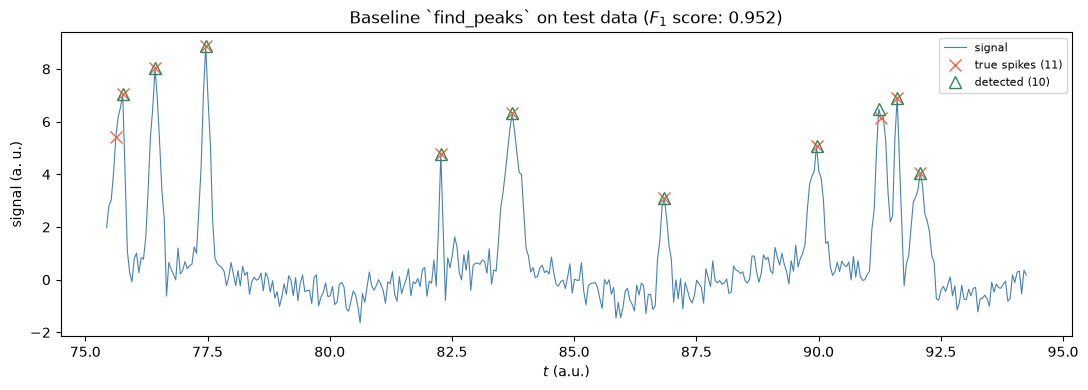

In [63]:
def plot_series_with_peaks(ds, ax, title, peaks2=None):
    sig = ds.y[0].numpy()
    t = ds.t.numpy()
    pk = ds.peak_indices.numpy()
    ax.plot(t, sig, lw=0.8, color="steelblue", label="signal")
    ax.plot(t[pk], sig[pk], "x", ms=9, color="tomato",
            label=f"true spikes ({pk.size})")
    ax.plot(t[baseline_test_peaks], sig[baseline_test_peaks], "^",
            color="seagreen", ms=9, mfc="none",
            label=f"detected ({baseline_test_peaks.shape[0]})")
    if peaks2 is not None:
        ax.plot(t[peaks2], sig[peaks2], "o",
            color="orange", ms=9, mfc="none",
            label=f"altx ({peaks2.shape[0]})")
    ax.set_title(title)
    ax.set_xlabel("$t$ (a.u.)")
    ax.set_ylabel("signal (a. u.)")
    ax.legend(loc="upper right", fontsize=8)


fig, axes = plt.subplots(figsize=(11, 4), sharey=True)
plot_series_with_peaks(test, axes, f"Baseline `find_peaks` on test data ($F_1$ score: {baseline_test_f1:.3f})")
plt.tight_layout()
plt.show()

## 3. Transform data with `ALTx`

In [64]:
train_set = train.y.unsqueeze(0)
anomaly_train = (train.labels == 1).nonzero(as_tuple=True)[0].tolist()

RLK = (None, 3, 1) # None: R=2L-1 (default case)
N = train_set.shape[-1]
boundaries = [-1] + anomaly_train + [N]

MIN_SEG = 2*RLK[1]   # a segment must be at least one embedding window long
segments = []
for lo, hi in zip(boundaries[:-1], boundaries[1:]):
    start, end = lo + 1, hi
    if end - start >= MIN_SEG:
        segments.append(train_set[..., start:end])

# Pad to a common length and stack into (instances, channels, max_len).
train_lengths = torch.tensor([seg.shape[-1] for seg in segments])
max_len = int(train_lengths.max())
train_segments = torch.cat(
    [F.pad(seg, (0, max_len - seg.shape[-1])) for seg in segments], dim=0
)
train_classes = torch.zeros(train_segments.shape[0])

print(f"{len(segments)} normal segments, lengths "
      f"{train_lengths.min().item()}..{train_lengths.max().item()}")

21 normal segments, lengths 6..136


In [65]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Altx(
    train_set=train_segments,
    train_classes=train_classes, # all filled with zeros, because we are not doing classification
    train_length=train_lengths,
    R=RLK[0], L=RLK[1], K=RLK[2],
    device=device
)
model.train()
model.print_number_of_laws()

def altx_score(ds):
    '''Transform a split into a 1-D anomaly score (+ aligned t and true peaks).

    The score is the mean squared projection of each window onto the learned
    laws (no normalisation, so the spike amplitude is preserved).
    '''
    transformed = model.multiply_only(z=ds.y, rlk=model.RLK[0], normalize_data=False)
    score = (transformed[:, :, 0] ** 2).mean(dim=1).cpu().numpy()
    t = ds.t.numpy()[: score.shape[0]]
    pk = ds.peak_indices.numpy()
    pk = pk[pk < score.shape[0]]      # keep spikes that survive the end trim
    return score, t, pk


val_score, val_t, val_peaks = altx_score(val)
test_score, test_t, test_peaks = altx_score(test)
print(f"transformed val: {val_score.shape}, test: {test_score.shape}")

Number of laws for r = 5, l = 3, k = 1:
(tensor([0.]), tensor([887]))
transformed val: (398,), test: (398,)


### 3.1. Combine `OptimizedFindPeaks` with `ALTx`

In [66]:
altx_opt = OptimizedFindPeaks(
    scorer="f1",
    n_trials=200,
    tolerance=TOLERANCE,
    seed=RANDOM_SEED
)

altx_opt.fit(val_score, val_peaks)

altx_test_f1, altx_test_peaks = peak_f1(test_score, test_peaks, altx_opt)

# Logging
print(f"Best params            : {altx_opt.best_params_}")
print(f"F1 score on VALIDATION : {altx_opt.best_score_:.3f}")
print(f"F1 score on TEST       : {altx_test_f1:.3f}")
print(f"Detected peaks         : {altx_test_peaks.size} from {test.peak_indices.shape[0]} peaks on test data.")

Best params            : {'height': 2.9861790807337982, 'prominence': 0.03086321707128284, 'distance': 5}
F1 score on VALIDATION : 1.000
F1 score on TEST       : 0.952
Detected peaks         : 10 from 11 peaks on test data.


## 4. Compare Results

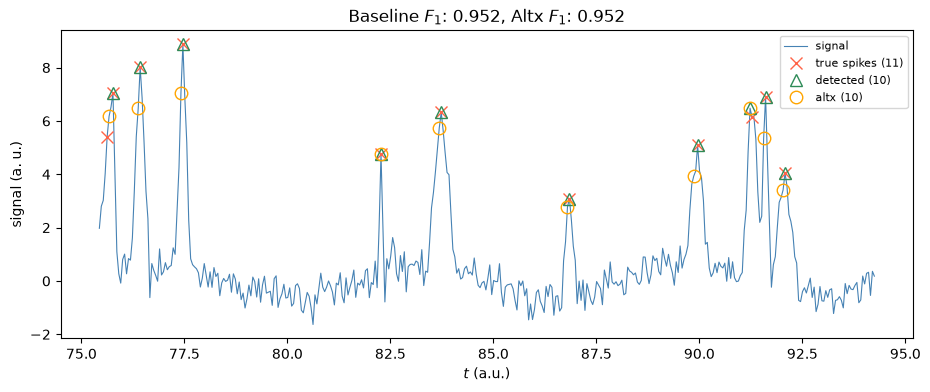

In [67]:
fig, axes = plt.subplots(1, 1, figsize=(11, 4), sharey=True)
plot_series_with_peaks(test, axes,
                       f"Baseline $F_1$: {baseline_test_f1:.3f}, Altx $F_1$: {altx_test_f1:.3f}",
                       peaks2=altx_test_peaks)


In [68]:
altx_test_peaks

array([  5,  20,  42, 145, 175, 241, 306, 335, 342, 352])

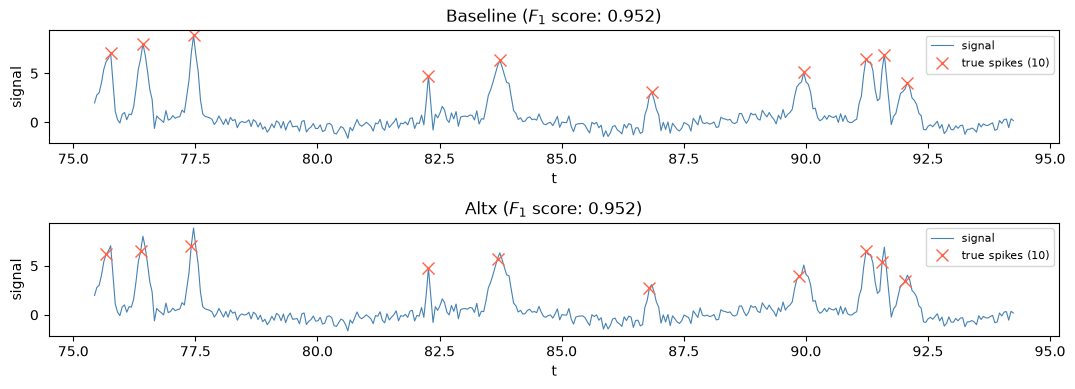

In [69]:
sig = test.y[0].numpy()
t = test.t.numpy()

fig, axes = plt.subplots(2, 1, figsize=(11, 4), sharey=True)
# Baseline
pk = baseline_test_peaks
axes[0].plot(t, sig, lw=0.8, color="steelblue", label="signal")
axes[0].plot(t[pk], sig[pk], "x", ms=9, color="tomato",
        label=f"true spikes ({pk.size})")
axes[0].set_title(f"Baseline ($F_1$ score: {baseline_test_f1:.3f})")
axes[0].set_xlabel("t")
axes[0].set_ylabel("signal")
axes[0].legend(loc="upper right", fontsize=8)

# ALTx
pk = altx_test_peaks
axes[1].plot(t, sig, lw=0.8, color="steelblue", label="signal")
axes[1].plot(t[pk], sig[pk], "x", ms=9, color="tomato",
        label=f"true spikes ({pk.size})")
axes[1].set_title(f"Altx ($F_1$ score: {altx_test_f1:.3f})")
axes[1].set_xlabel("t")
axes[1].set_ylabel("signal")
axes[1].legend(loc="upper right", fontsize=8)

#plot_series_with_peaks(test, axes[0], f"Baseline `find_peaks` on test data ($F_1$ score: {baseline_test_f1:.3f})")
#plot_series_with_peaks(test, axes[1], f"Baseline `find_peaks` on test data ($F_1$ score: {altx_test_f1:.3f})")
plt.tight_layout()
plt.show()